In [1]:
# import necessary general dependencies
%load_ext autoreload
%autoreload 2
import sys
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
sys.path.append('../modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# Load preprocessed data
processed_datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1VuhAbDh00i2_v1fMyvocOLzmzc01svrQ', 'filename': 'merged_clean.csv'}
]

get_data.get_raw(processed_datafiles,destination_directory='../data/02-processed/')

df_merged = pd.read_csv('../data/02-processed/merged_clean.csv')

Overall Download Progress: 100%|██████████| 1/1 [00:01<00:00,  1.81s/it]         

Successfully downloaded: merged_clean.csv


### Analysis 4 Code: Random Forest Regression on Full Time Period (1996-2022)


========== FULL-PERIOD RANDOM FOREST ==========

5-Fold Cross-Validated R²: 0.6606 ± 0.0837
5-Fold Cross-Validated RMSE: 0.0366 ± 0.0061

========== Permutation Importance (Full Period) ==========

Full-Period Permutation Importance:
   feature  importance
      VORP    0.177874
       PER    0.093718
       BPM    0.082860
net_rating    0.070034
     WS/48    0.066999
       pts    0.054179
   usg_pct    0.043063
       TOV    0.039529
       ast    0.016171
       BLK    0.011274
    ts_pct    0.011160
       reb    0.010853
      eFG%    0.009632
       FTr    0.009031
  dreb_pct    0.008139
       STL    0.006370
  oreb_pct    0.006112


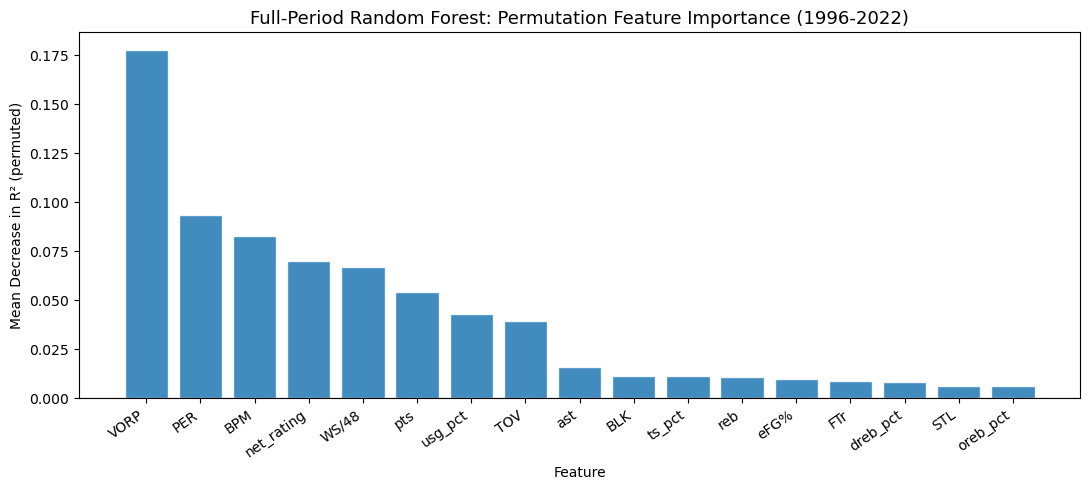

In [9]:
# This cell sets up and carries out the Random Forest Regression on all players within the dataset across the entire time period from 1996-2022
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.inspection import permutation_importance
 
traditional_vars = ['pts', 'ast', 'reb', 'STL', 'BLK', 'TOV']
advanced_vars    = ['ts_pct', 'usg_pct', 'net_rating', 'WS/48', 'BPM', 'VORP', 'PER', 'eFG%', 'oreb_pct', 'dreb_pct', 'FTr']
all_predictors   = traditional_vars + advanced_vars
target           = 'share'
 
# add era column to df_merged
df_merged['start_year'] = df_merged['season'].str[:4].astype(int)
df_merged['era'] = df_merged['start_year'].apply(
    lambda s: 'pre_analytics' if s < 2004 else 'modern'
)
 
# use all players for the random forest regression model
df_model = df_merged[all_predictors + [target, 'era', 'Player', 'season']].dropna()

X = df_model[all_predictors]
y = df_model[target]

# fit full period random forest regressor
print("\n========== FULL-PERIOD RANDOM FOREST ==========")
 
rf_full = RandomForestRegressor(
    n_estimators=500,      # number of trees
    min_samples_leaf=5,    # prevents overfitting on small groups
    max_features='sqrt',   # standard for regression RF
    random_state=42,
)
rf_full.fit(X, y)
 
# use 5-fold cross-validated performance
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf_full, X, y, cv=kf, scoring='r2')
cv_rmse = cross_val_score(rf_full, X, y, cv=kf, scoring='neg_root_mean_squared_error')

print(f"\n5-Fold Cross-Validated R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"5-Fold Cross-Validated RMSE: {(-cv_rmse).mean():.4f} ± {(-cv_rmse).std():.4f}")

# save metric output to a csv
metrics = {
    'cv_r2_mean': cv_r2.mean(),
    'cv_r2_std': cv_r2.std(),
    'cv_rmse_mean': (-cv_rmse).mean(),
    'cv_rmse_std': (-cv_rmse).std()
}
pd.Series(metrics).to_csv('../results/rf_full_metrics.csv')
 
 
# run permutation importance on the features for the full period random forest regression model
print("\n========== Permutation Importance (Full Period) ==========")
 
perm_full = permutation_importance(
    rf_full, X, y,
    n_repeats=30,     
    random_state=42,
)
 
# organize into a DataFrame with mean across repeats
perm_full_df = pd.DataFrame({
    'feature':   all_predictors,
    'importance': perm_full.importances_mean
}).sort_values('importance', ascending=False)
 
print("\nFull-Period Permutation Importance:")
print(perm_full_df.to_string(index=False))
 
# plot the mean permutation importance of all features in a bar graph
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    perm_full_df['feature'], perm_full_df['importance'],
    edgecolor='white', capsize=4, alpha=0.85
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(perm_full_df['feature'])))
ax.set_xticklabels(perm_full_df['feature'], rotation=35, ha='right')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean Decrease in R² (permuted)')
ax.set_title('Full-Period Random Forest: Permutation Feature Importance (1996-2022)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/rf_permutation_importance_full.png', dpi=150, bbox_inches='tight')
plt.show()


Pre-Analytics (1996-2004)  (n=2944)
  5-Fold CV R²: 0.5343 ± 0.1096

  Permutation importance ranking — Pre-Analytics (1996-2004):
PER           0.137842
BPM           0.081411
VORP          0.076689
WS/48         0.055146
net_rating    0.050925
pts           0.044056
usg_pct       0.025234
reb           0.019406
TOV           0.017668
ast           0.017594
BLK           0.008994
ts_pct        0.008216
STL           0.006745
oreb_pct      0.006474
dreb_pct      0.005447
eFG%          0.005176
FTr           0.005096

Modern (2004-2022)  (n=7340)
  5-Fold CV R²: 0.6485 ± 0.1516

  Permutation importance ranking — Modern (2004-2022):
VORP          0.174827
PER           0.077756
BPM           0.075982
WS/48         0.068486
net_rating    0.049373
pts           0.040003
usg_pct       0.038820
TOV           0.034110
ast           0.018407
ts_pct        0.015150
eFG%          0.009208
dreb_pct      0.007228
reb           0.006860
FTr           0.006266
BLK           0.006069
oreb_pct      

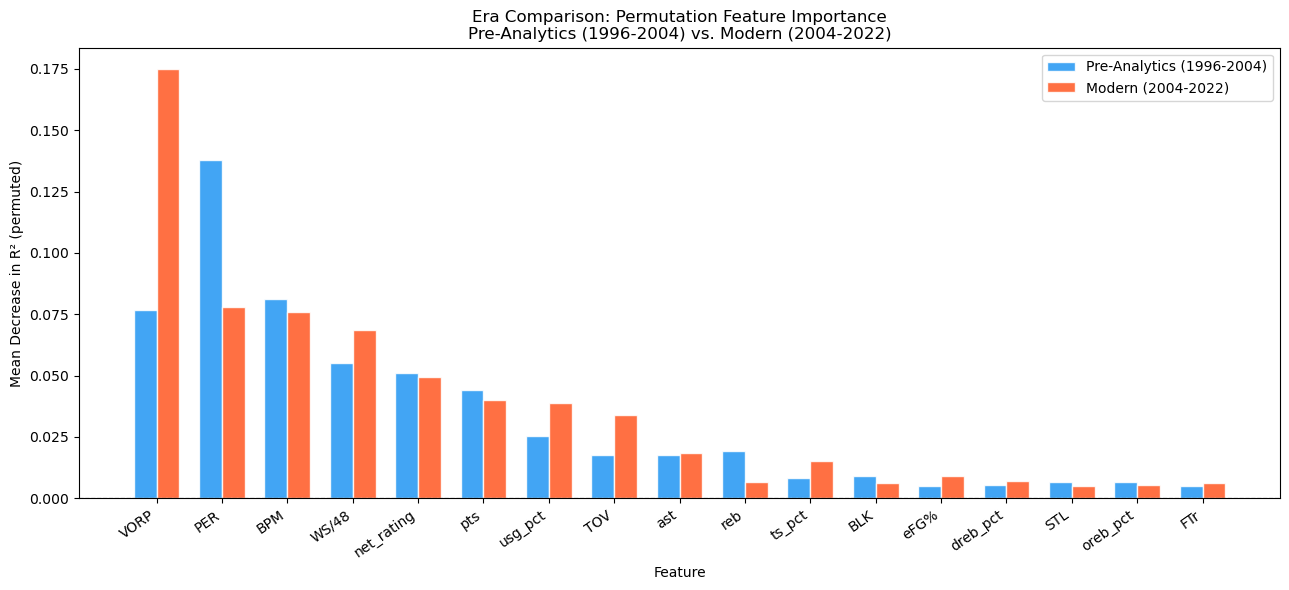

In [5]:
# This cell sets up and carries out the era-split Random Forest Regression on all players within the dataset
# stratified by the pre-analytics (1996-2004) and modern eras (2004-2022)

perm_era_results = {}
era_metrics = {}

# fit a separate random forest regressor for each era and compute permutation importance
for era_name, label in [('pre_analytics', 'Pre-Analytics (1996-2004)'),
                         ('modern', 'Modern (2004-2022)')]:
    df_era = df_model[df_model['era'] == era_name]
    X_era  = df_era[all_predictors]
    y_era  = df_era[target]

    rf_era = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
    )
    rf_era.fit(X_era, y_era)

    # use 5-fold cross-validated R² per era
    cv_r2_era = cross_val_score(rf_era, X_era, y_era, cv=5, scoring='r2')
    print(f"\n{label}  (n={len(df_era)})")
    print(f"  5-Fold CV R²: {cv_r2_era.mean():.4f} ± {cv_r2_era.std():.4f}")
    era_metrics[era_name] = {
        'cv_r2_mean': cv_r2_era.mean(),
        'cv_r2_std': cv_r2_era.std()
    }
        
    # run permutation importance for this era
    perm_era = permutation_importance(
        rf_era, X_era, y_era,
        n_repeats=30,
        random_state=42,
    )
    perm_era_results[era_name] = pd.Series(
        perm_era.importances_mean, index=all_predictors
    )

    # print permutation importance ranking for this era
    print(f"\n  Permutation importance ranking — {label}:")
    print(perm_era_results[era_name].sort_values(ascending=False).to_string())

# save cross-validated R^2 results to csv
pd.DataFrame(era_metrics).to_csv('../results/rf_era_metrics.csv')

# save era permutation importance results to csv
perm_compare = pd.DataFrame(perm_era_results).rename(columns={
    'pre_analytics': 'Pre-Analytics (1996-2004)',
    'modern': 'Modern (2004-2022)'
})

# sort by total importance across both eras
perm_compare['total'] = perm_compare.sum(axis=1)
perm_compare = perm_compare.sort_values('total', ascending=False).drop(columns='total')
perm_compare.to_csv('../results/rf_era_permutation_importance.csv')

# plot era comparison of permutation importance side by side
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(perm_compare))
width  = 0.35
colors = ['#2196F3', '#FF5722']

for i, col in enumerate(perm_compare.columns):
    ax.bar(x + (i - 0.5) * width, perm_compare[col], width,
           label=col, color=colors[i], alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(perm_compare.index, rotation=35, ha='right')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean Decrease in R² (permuted)')
ax.set_title('Era Comparison: Permutation Feature Importance\n'
             'Pre-Analytics (1996-2004) vs. Modern (2004-2022)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../results/rf_permutation_era_comparison.png', dpi=150, bbox_inches='tight')
plt.show()